# Neuron ↔ MLE-parameter correlation (2-photon × RL model)

For a chosen saved **MLE fit**, re-evaluate its trial-by-trial latents
(Q-Left, Q-Right, relative Q "Q-val", RewardRate) and ask, **per neuron**,
whether that neuron's per-trial sampling-window max activity correlates with
each latent.

This notebook is a thin config layer over `model/neural_correlate.py` (same
split as `model_compare.ipynb` → `model/compare.py`). Activity comes from the
z-scored + time-normalized sampling-window df; correlation is Pearson, within
session; latents are the before-trial values; brain region is MFC / LFC.

In [1]:
%load_ext autoreload
%autoreload 2
if "PKG" not in globals():
    root_parent_level = 2
    import importlib, sys, pathlib # https://stackoverflow.com/a/50395128/11996983
    PKG = %pwd
    PKG = pathlib.Path(PKG)
    root = PKG
    full_pkg = f"{root.name}"
    for _ in range(root_parent_level):
        root = root.parent
        full_pkg = f"{root.name}.{full_pkg}"
        MODULE_PATH = f"{root}{pathlib.os.path.sep}__init__.py"
        MODULE_NAME = f"{root.name}"
        spec = importlib.util.spec_from_file_location(MODULE_NAME, MODULE_PATH)
        module = importlib.util.module_from_spec(spec)
        sys.modules[spec.name] = module
        spec.loader.exec_module(module)
    __package__ = full_pkg

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]

## Config

Declare the model fit and the 2-photon activity source here; everything below
is a call into the backend.

In [3]:
from pathlib import Path

# The saved MLE fit to correlate against (a {subject: payload} pickle).
MODEL_FIT_PATH = "../../data/RLModel/mle_NoiseGain-RewardRate_biasQ-Val (Offset)_Normal(0, 1)_4.8s_dt0.005_mleW1_chi2W0.5.pkl"

# 2-photon sampling-window activity: z-scored + time(width)-normalized,
# window = sampling +0.1s before / +0.1s after. Both the stored trace and the
# np.nanmax activity come from this file.
TWOP_ACTIVITY_PATH = "../../data/2p/normalized_0.1s_before_sampling_0.1s_after_movement.pkl"

# Reuse the per-trial latents already stored inside the fit file (fast, and no
# behavior df needed). Set False to RECOMPUTE them via MLE (expensive; then the
# behavior df is loaded and passed in).
REUSE_FIT_DF = True

# Where saved per-neuron figures + region bars are written.
BASE_SAVE_PATH = "../../results/RLModel/neural_correlate"

# --- Save toggles ------------------------------------------------------------
# Two independent switches for writing figures to disk under BASE_SAVE_PATH:
#   SAVE_SUMMARY_FIGS — the summary bar charts (tuning / factor / fast-vs-slow),
#                       one figure + summary CSV per view.
#   SAVE_NEURON_FIGS  — the per-neuron single-trace correlates and whole-trace
#                       figures (scatters + range-averaged traces). These write
#                       ONE file per tuned neuron, so keep this off unless you
#                       actually want the full per-neuron dump.
SAVE_SUMMARY_FIGS = False
SAVE_NEURON_FIGS = False

# Drop the worst-loss trials (per subject) before correlating? The lapse
# mixture means the worst per-trial loss is not a fixed floor.
EXCLUDE_MAX_LOSS = False

# A neuron counts as "tuned" to a parameter when |Pearson r| >= this. Also the
# threshold used to save ONLY the tuned subset of per-neuron figures.
MIN_ABS_CORR = 0.3

# --- Significance testing on the summary bar charts --------------------------
# RUN_STATS is the master switch: True runs the permutation / hierarchical-
# bootstrap tests and annotates */**/*** stars; set it False for a fast
# plot-only pass (bars + SEM only, no shuffles/bootstrap).
RUN_STATS = True
# Neuron-level permutations for the "vs chance" shuffle test (per-neuron activity
# shuffle) and for the session-paired fast-vs-slow permutation.
N_SHUFFLES = 1000
N_PERM = N_SHUFFLES
# Hierarchical-bootstrap draws (region -> session -> neuron, with replacement)
# for the MFC-vs-LFC cross-region comparisons. Lower it for quick runs.
N_BOOT = 10000

# Display: how many top-|r| neurons to show; z-score the scatter's activity axis?
TOP_X = 15
ZSCORE_ACTIVITY = False

# Which parameter the example scatter / trace cells use.
PARAM = "Q_val"

# Bin EDGES per parameter for the per-neuron trace-average plot: N edges -> N-1
# bins; a trial joins bin i when edge[i] <= value < edge[i+1] (last bin includes
# its right edge). NOTE: placeholder edges — replace with the intended ones.
PARAM_VALUE_RANGES = {
    "Q_L":        [0, 0.6, 0.7, 0.85, 1.001],
    "Q_R":        [0, 0.6, 0.7, 0.85, 1.001],
    "Q_val":      [-1.001,-0.20, -0.005, 0.005, 0.20, 1.001],
    "RewardRate": [0, 0.4, 0.6, 0.8, 1.001],
}

# Same for the fast/slow drift traces: DV is signed evidence [-1,1]; DVabs is
# evidence magnitude [0,1]. NOTE: placeholder edges — replace as needed.
DRIFT_VALUE_RANGES = {
    "DV":    [-1.001, -0.65, -0.35, -0.001, 0.001, 0.35, 0.65, 1.001],
    "DVabs": [0, 0.35, 0.65, 1.001],
}

## Load

Load the 2-photon activity **first**, take the imaged subjects from it, then
load the MLE latents for **only those subjects** (the fit file usually holds
many un-imaged subjects too). `load_mle_per_trial` reports which latent families
the fit learns (`include_Q` / `include_RewardRate`) and returns only those. With
`REUSE_FIT_DF=True` it reads the per-trial df already stored in the fit (fast, no
behavior df needed).

In [4]:
from .model import neural_correlate as nc

# 1) Load 2-photon activity first, and see which subjects were actually imaged.
df_2p = nc.load_2p_activity(TWOP_ACTIVITY_PATH)
subjects = nc.subjects_in_2p(df_2p)
print("Imaged subjects:", subjects)

# 2) Load the MLE latents for ONLY those subjects. When recomputing we also need
#    the behavior df; when reusing the stored fit df we don't.
df_behavior = None if REUSE_FIT_DF else nc.prepare_behavior_df()
mle_pt, PARAM_KEYS = nc.load_mle_per_trial(
    MODEL_FIT_PATH, df_behavior, subjects=subjects, reuse_fit_df=REUSE_FIT_DF)
# Friendly model name (includes the weighted-Chi² tag) for titles + save paths.
MODEL_NAME = mle_pt.model_label.iloc[0]
print("Model:", MODEL_NAME)
print("Available parameters:", PARAM_KEYS)

Imaged subjects: ['GP4-23', 'GP4-24', 'GP4-28', 'GP4-80', 'GP4-81', 'GP4-85']
  2 requested subject(s) absent from the fit file: ['GP4-23', 'GP4-28']
Model: RewardRate · Q-Val (Offset) · Normal(0, 1) · 4.8s · weighted Chi² (MLE=1, Chi²=0.5)
  subjects loaded: ['GP4-24', 'GP4-80', 'GP4-81', 'GP4-85']
  mode: reuse stored mle_df
  include_Q=True  include_RewardRate=True
  Correlatable parameters: Q_L, Q_R, Q_val, RewardRate
Model: RewardRate · Q-Val (Offset) · Normal(0, 1) · 4.8s · weighted Chi² (MLE=1, Chi²=0.5)
Available parameters: ['Q_L', 'Q_R', 'Q_val', 'RewardRate']


## Intermediate table + per-neuron correlations

`table` is one row per (neuron, matched trial): max activity, the full
time-normalized trace, and the latents. `corr_df` is one row per neuron with
`{param}_r` / `{param}_p` (within-session Pearson).

In [5]:
table = nc.build_neuron_trial_table(df_2p, mle_pt, PARAM_KEYS,
                                    exclude_max_loss=EXCLUDE_MAX_LOSS)
print(f"{table.long_trace_id.nunique()} neurons · {len(table)} (neuron×trial) rows")
table.head()

584 neurons · 131628 (neuron×trial) rows


,trace_id,long_trace_id,BrainRegion,ShortName,TrialNumber,max_activity,trace,epochs_ranges,epochs_names,DV,DVabs,quantile_idx,Q_L,Q_R,Q_val,RewardRate
0,1,GP4_24_s4_L85_D250_M2_1,MFC,GP4_24_s4_L85_D250_M2,119,-0.049659,"[-0.4802003, -0.4641595, -0.4109047, -0.403866...","((0, 2), (3, 29), (30, 32))","[-0.1s Sampling, Sampling, Movement to Lateral...",-0.5,0.5,3,0.859729,0.807296,0.013664,0.780864
1,2,GP4_24_s4_L85_D250_M2_2,MFC,GP4_24_s4_L85_D250_M2,119,-0.197314,"[-0.8525737, -0.6850297, -0.47221366, -0.33689...","((0, 2), (3, 29), (30, 32))","[-0.1s Sampling, Sampling, Movement to Lateral...",-0.5,0.5,3,0.859729,0.807296,0.013664,0.780864
2,3,GP4_24_s4_L85_D250_M2_3,MFC,GP4_24_s4_L85_D250_M2,119,-0.338939,"[-0.58463955, -0.5942389, -0.71961886, -0.8497...","((0, 2), (3, 29), (30, 32))","[-0.1s Sampling, Sampling, Movement to Lateral...",-0.5,0.5,3,0.859729,0.807296,0.013664,0.780864
3,5,GP4_24_s4_L85_D250_M2_5,MFC,GP4_24_s4_L85_D250_M2,119,-0.017965,"[-0.28918448, -0.13945785, -0.023446966, -0.01...","((0, 2), (3, 29), (30, 32))","[-0.1s Sampling, Sampling, Movement to Lateral...",-0.5,0.5,3,0.859729,0.807296,0.013664,0.780864
4,9,GP4_24_s4_L85_D250_M2_9,MFC,GP4_24_s4_L85_D250_M2,119,0.857584,"[-0.2088601, -0.30529004, -0.1775805, 0.186450...","((0, 2), (3, 29), (30, 32))","[-0.1s Sampling, Sampling, Movement to Lateral...",-0.5,0.5,3,0.859729,0.807296,0.013664,0.780864


In [6]:
corr_df = nc.compute_neuron_correlations(table, PARAM_KEYS)
corr_df.head()

,trace_id,long_trace_id,BrainRegion,ShortName,n_trials,Q_L_r,Q_L_p,Q_R_r,Q_R_p,Q_val_r,Q_val_p,RewardRate_r,RewardRate_p
0,1,GP4_24_s4_L85_D250_M2_1,MFC,GP4_24_s4_L85_D250_M2,179,-0.119818,1.101367e-01,0.132227,0.077657,-0.152149,0.042032,0.067328,3.705263e-01
1,10,GP4_24_s4_L85_D250_M2_10,MFC,GP4_24_s4_L85_D250_M2,179,-0.304300,3.452357e-05,-0.239324,0.001253,-0.053441,0.477400,-0.372912,2.733889e-07
2,114,GP4_24_s4_L85_D250_M2_114,MFC,GP4_24_s4_L85_D250_M2,179,-0.128434,8.663883e-02,0.272954,0.000218,-0.250433,0.000722,0.104104,1.654919e-01
3,12,GP4_24_s4_L85_D250_M2_12,MFC,GP4_24_s4_L85_D250_M2,179,-0.161435,3.085791e-02,-0.020947,0.780771,-0.095246,0.204706,-0.115501,1.236500e-01
4,13,GP4_24_s4_L85_D250_M2_13,MFC,GP4_24_s4_L85_D250_M2,179,-0.356226,9.875926e-07,-0.222437,0.002765,-0.097196,0.195545,-0.399244,3.093715e-08


## Per-neuron scatters (activity vs parameter)

Top-`TOP_X` neurons by `|r|` for `PARAM`. y = Neuron Activity, x = the latent.

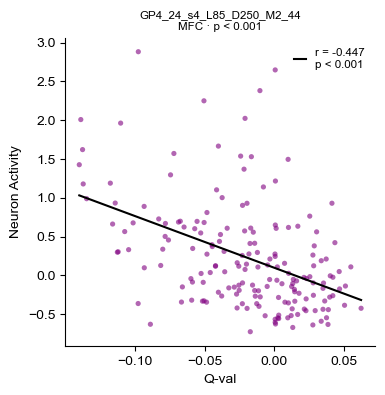

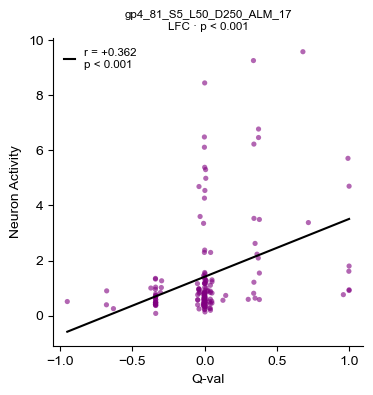

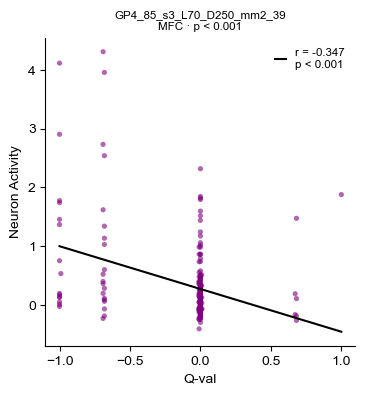

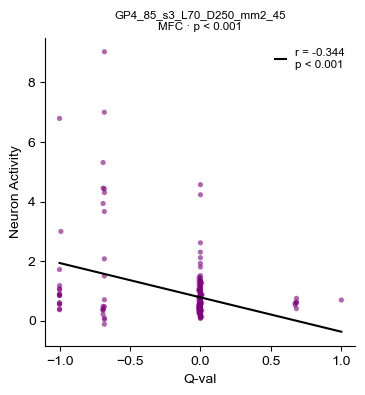

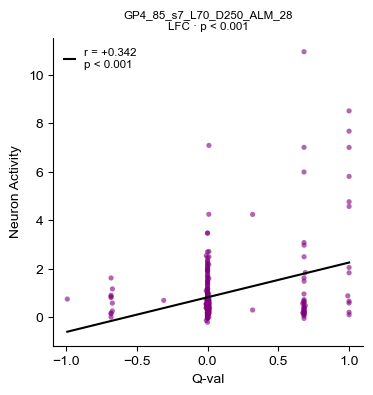

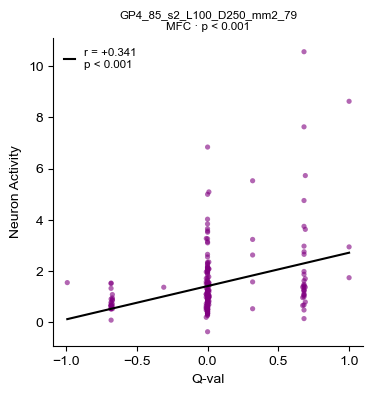

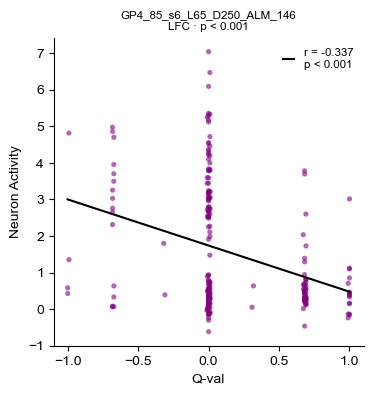

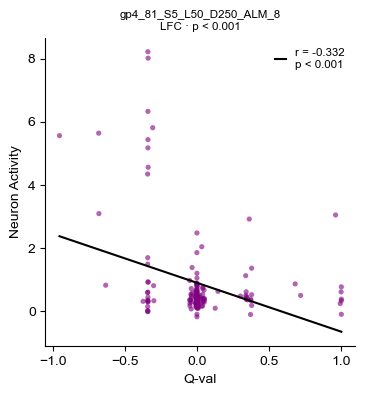

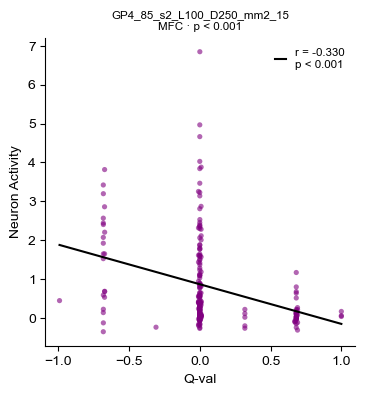

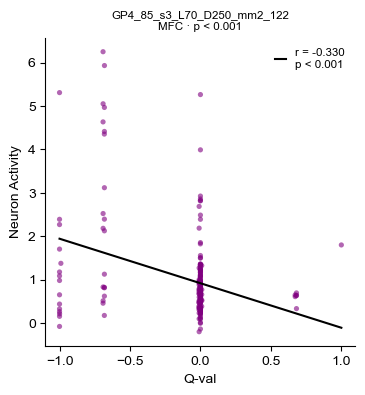

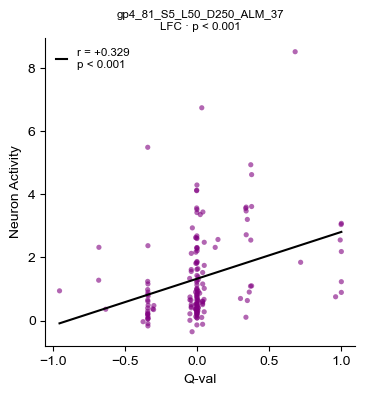

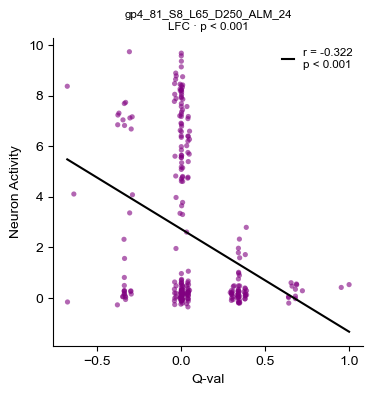

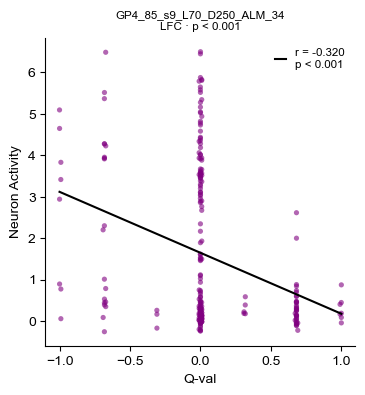

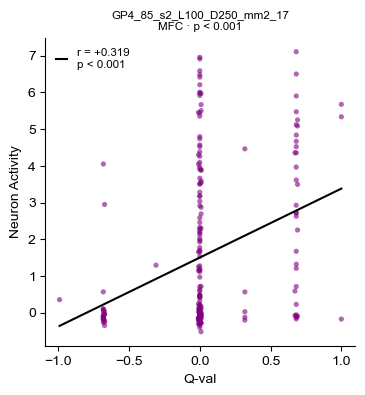

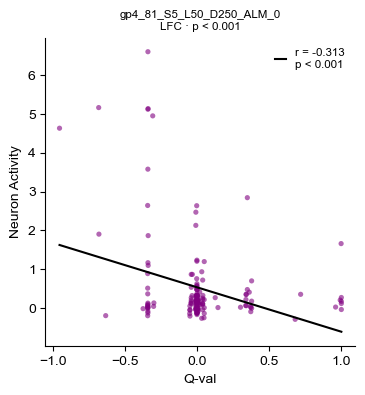

In [7]:
_ = nc.plot_neuron_results(table, corr_df, PARAM, mode="display",
                           top_x=TOP_X, zscore=ZSCORE_ACTIVITY)

In [8]:
# Save each TUNED neuron's scatter (|r| >= MIN_ABS_CORR) for EVERY parameter:
#   {BASE_SAVE_PATH}/{model}/traces/{param}/{signed_r}_{long_name}[_region].svg
# Gated by SAVE_NEURON_FIGS (Config) — one file per tuned neuron.
if SAVE_NEURON_FIGS:
    for key in PARAM_KEYS:
        nc.plot_neuron_results(table, corr_df, key, mode="save",
                               zscore=ZSCORE_ACTIVITY, min_abs_corr=MIN_ABS_CORR,
                               save_root=BASE_SAVE_PATH, model_name=MODEL_NAME)

## Per-neuron trace averages by parameter value range

For each neuron, the time-normalized trace is averaged (mean ± SEM) within each
value range of `PARAM` (from `PARAM_VALUE_RANGES`), all overlaid in one axes and
gradient-coloured (pale → the parameter's bar colour). Dashed lines mark
sampling start and movement start. `mode="display"` shows the top-`TOP_X`
neurons; `mode="save"` writes the tuned subset (`|r| >= MIN_ABS_CORR`) under
`{model}/param_traces/{param}/`.

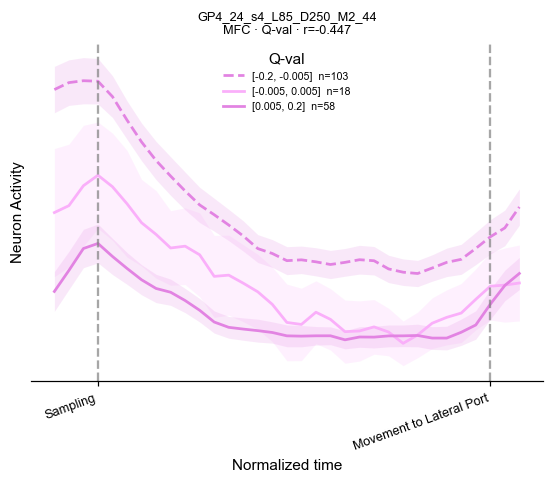

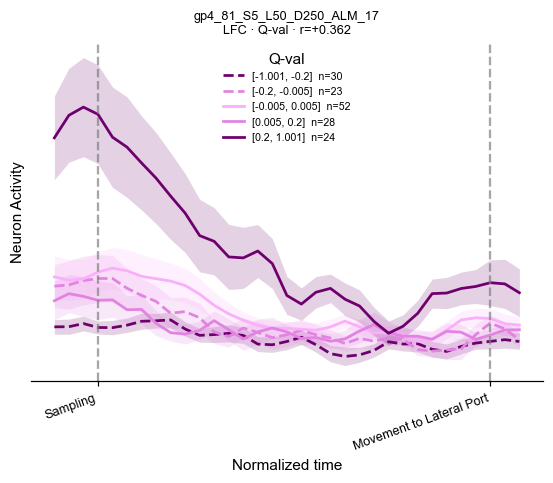

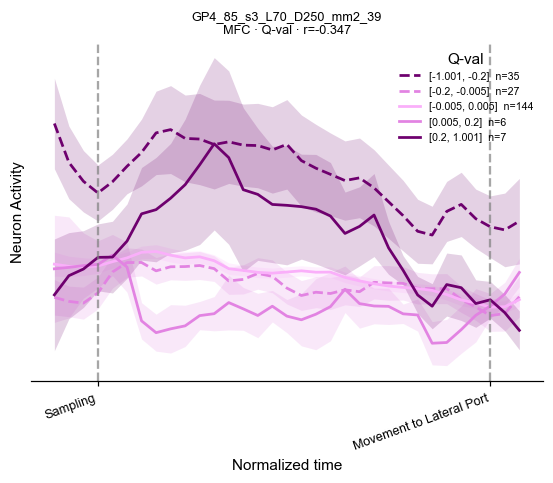

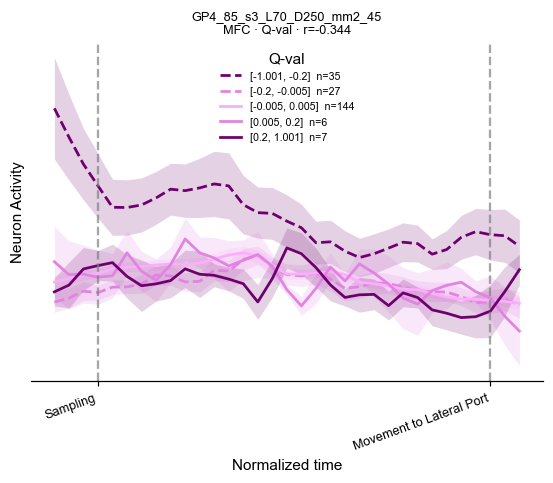

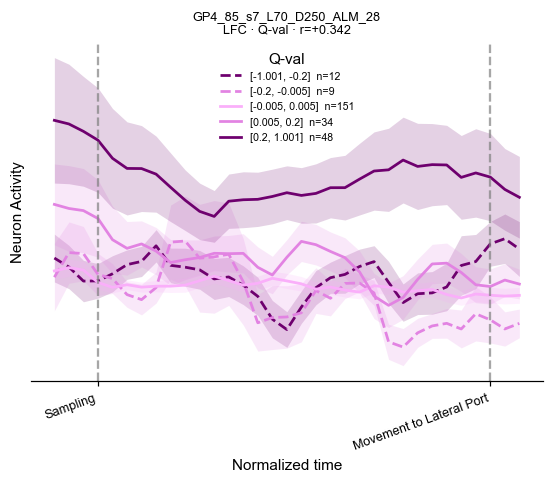

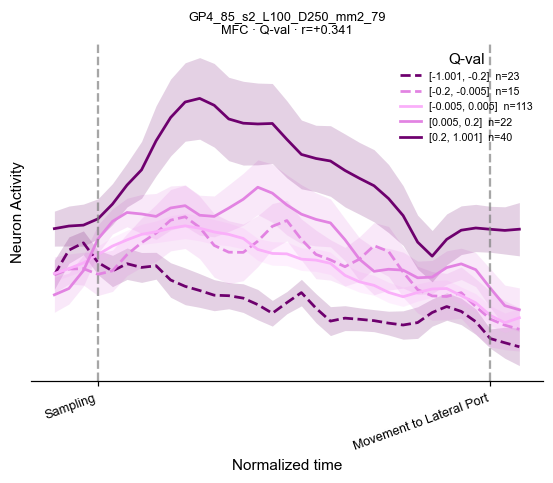

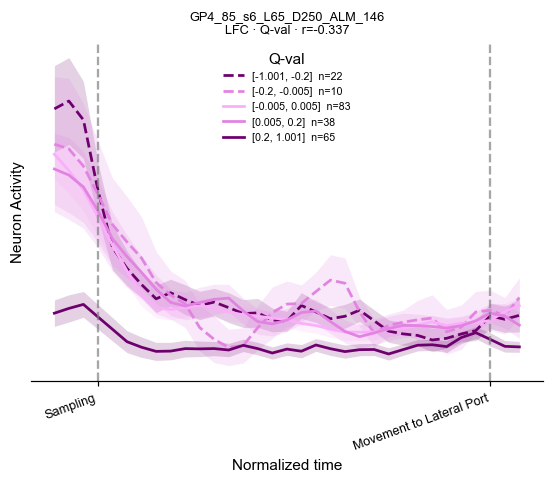

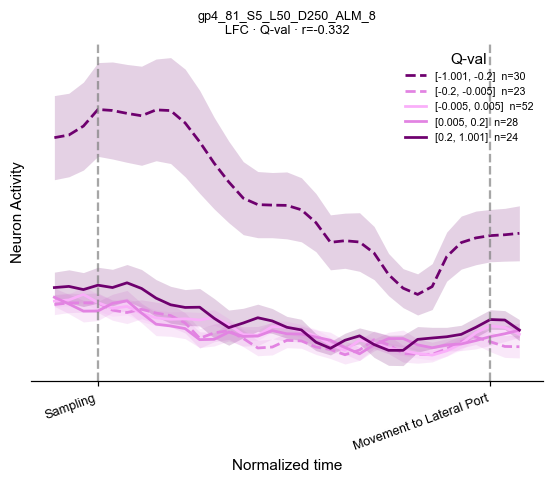

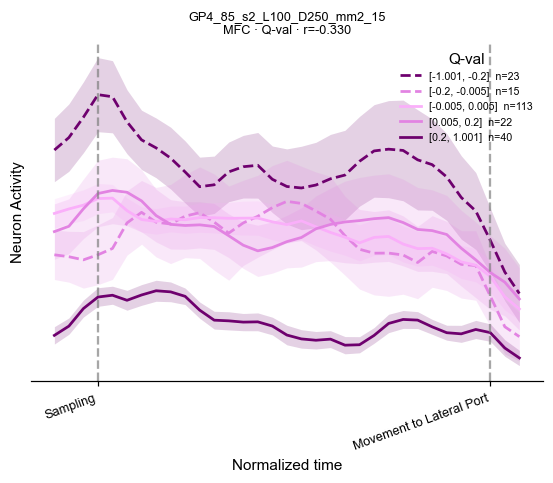

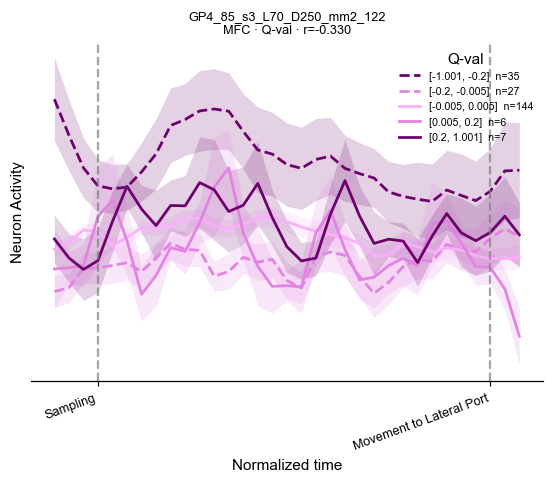

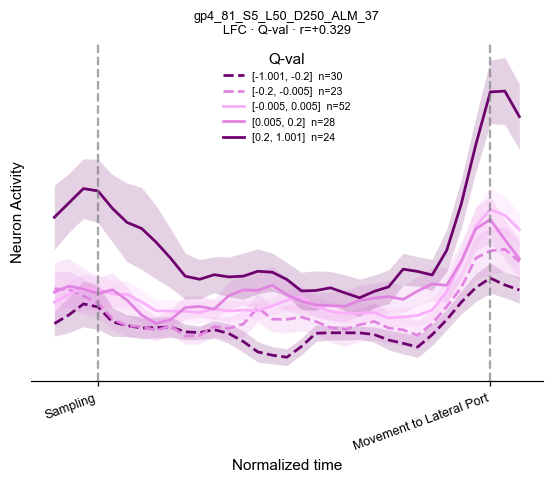

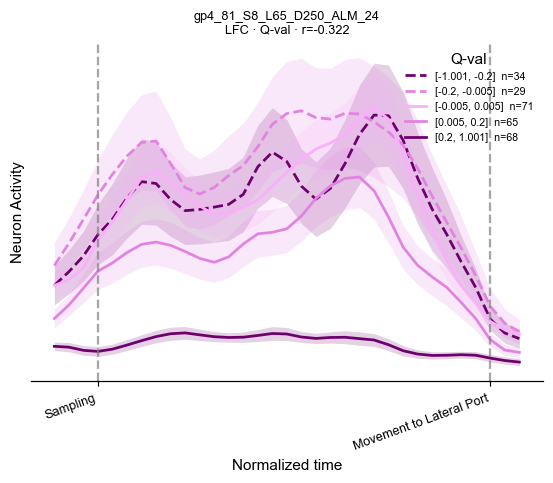

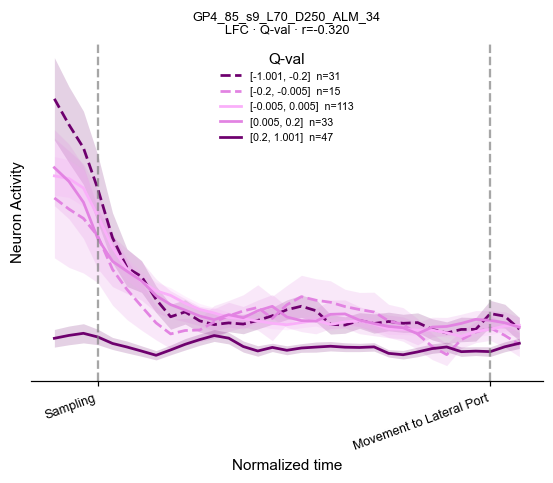

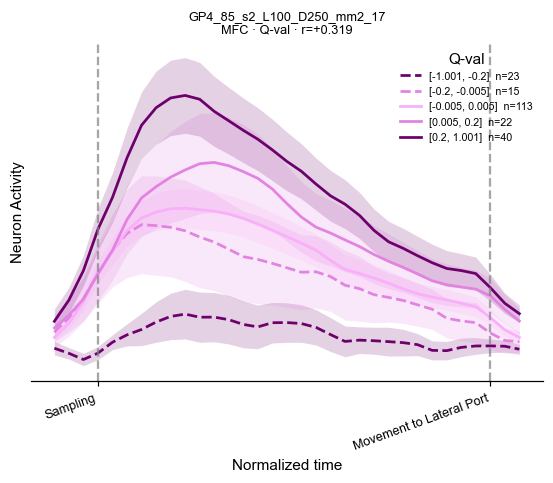

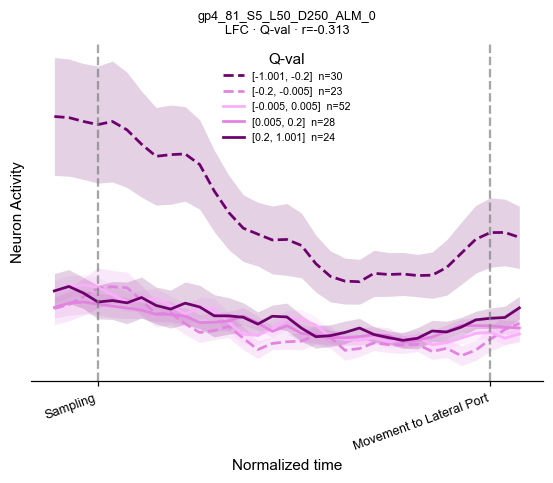

In [9]:
# Display the top-TOP_X tuned neurons' range-averaged traces for PARAM:
# _PARAM = "Q_R"
_PARAM = PARAM
_ = nc.plot_neuron_param_traces(table, corr_df, _PARAM, PARAM_VALUE_RANGES[_PARAM],
                                mode="display", top_x=TOP_X)


In [10]:
# Save the tuned subset for every parameter:
#   {BASE_SAVE_PATH}/{model}/param_traces/{param}/{signed_r}_{long_name}[_region].svg
# Gated by SAVE_NEURON_FIGS (Config) — one file per tuned neuron.
if SAVE_NEURON_FIGS:
    for key in PARAM_KEYS:
        nc.plot_neuron_param_traces(table, corr_df, key, PARAM_VALUE_RANGES[key],
                                    mode="save", min_abs_corr=MIN_ABS_CORR,
                                    save_root=BASE_SAVE_PATH, model_name=MODEL_NAME)

## Fraction-tuned bars (per brain region)

One coloured bar per parameter = the % of tuned neurons, **session mean ± SEM**
(the distribution of per-session percentages within a region). Each bar is
tested against a per-neuron activity-shuffle chance level (`N_SHUFFLES`
permutations, `+1/(n+1)` p-value); the p-values are Holm-corrected across the
bars of a panel and shown as `*/**/***` (`n.s.` otherwise). `by_region=True`
gives one panel per MFC/LFC; `by_region=False` pools everything. Set
`RUN_STATS=False` (Config) to skip the permutation for a fast plot-only pass.
Always shown; `save=True` also writes the figure + summary under
`{model}/tuning_bars/`.

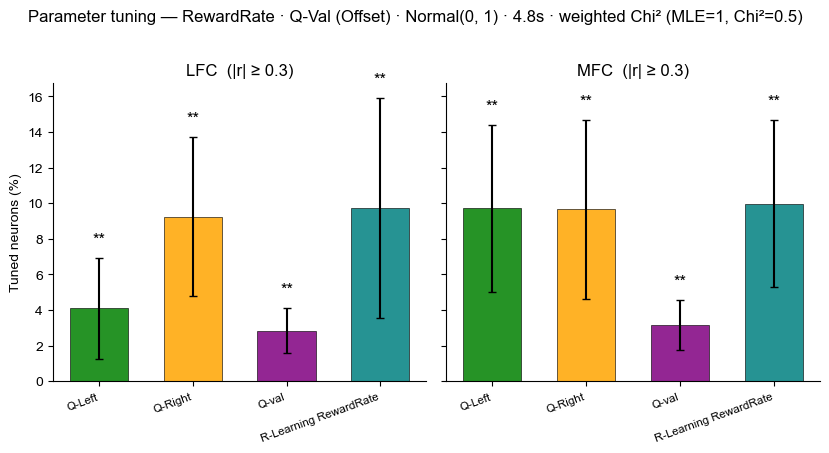

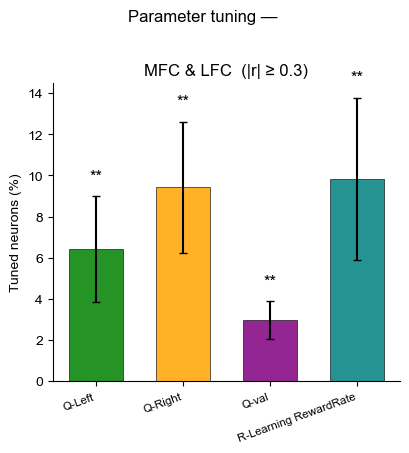

,BrainRegion,param,observed_pct,observed_sem,shuffle_pct,ci2.5,ci97.5,n_sessions,p_vs_shuffle,p_vs_shuffle_holm
0,LFC,Q_L,4.081633,2.832199,0.005332,0.0,0.000000,7,0.000999,0.003996
1,LFC,Q_R,9.248171,4.471185,0.006677,0.0,0.000000,7,0.000999,0.003996
2,LFC,Q_val,2.837059,1.275416,0.004225,0.0,0.000000,7,0.000999,0.003996
3,LFC,RewardRate,9.754224,6.180154,0.004020,0.0,0.000000,7,0.000999,0.003996
4,MFC,Q_L,9.713889,4.706222,0.001200,0.0,0.000000,5,0.000999,0.003996
5,MFC,Q_R,9.650000,5.027176,0.013561,0.0,0.266667,5,0.000999,0.003996
6,MFC,Q_val,3.158333,1.420118,0.000933,0.0,0.000000,5,0.000999,0.003996
7,MFC,RewardRate,9.980556,4.703664,0.003158,0.0,0.000000,5,0.000999,0.003996


In [11]:
# One bar per parameter, split by brain region, with the neuron-level shuffle
# baseline + permutation p-value. Needs `table` (per-trial data) for the shuffle.
# Significance (*/**/***) is Holm-corrected across the bars of each panel; set
# RUN_STATS=False in Config for a fast plot-only pass.
summary = nc.plot_region_bars(corr_df, table, min_abs_corr=MIN_ABS_CORR,
                              n_shuffles=N_SHUFFLES, by_region=True,
                              run_stats=RUN_STATS, save=SAVE_SUMMARY_FIGS,
                              save_root=BASE_SAVE_PATH, model_name=MODEL_NAME)
# ... and pooled across regions (everything together):
_ = nc.plot_region_bars(corr_df, table, min_abs_corr=MIN_ABS_CORR, save=False,
                        n_shuffles=N_SHUFFLES, by_region=False,
                        run_stats=RUN_STATS)
summary

## Factor modulation bars (Q / Reward-Rate / DV, all trials)

Collapse related parameters into one **modulation factor**: a neuron is modulated
by a factor when `|r| >= MIN_ABS_CORR` for **any** of its params — counted
**once** (the correlation df is one row per neuron, so a neuron tuned to two Q
params is not double-counted). Three views:

1. **DV** alone, over **all** trials (the same drift as the fast/slow section
   below, but not split);
2. **Q** = Q-left/right/val collapsed into one "Q-modulated" bar;
3. **Q vs Reward-Rate vs DV** side by side, with **DV split into fast | slow**
   touching sub-bars (correlated *within* each RT tercile).

Bars are session mean ± SEM. In every view the significance stars test each bar
against its per-neuron activity-shuffle chance level (Holm across the bars). For
(3) the by-region view draws **MFC and LFC as two separate figures** sharing one
y-range (no cross-region comparison): the vs-chance stars are Holm-corrected
across the 4 bars *within each region*, and a session-paired **DV fast-vs-slow**
permutation bracket sits over the DV pair. `corr_all` adds DV to the correlations
(`PARAM_KEYS + ["DV"]`). Set `RUN_STATS=False` (Config) to skip all tests.

In [12]:
# DV lives on the 2P trial row (not the MLE latents), so add it to the
# correlations here. corr_all = the per-neuron r/p for Q_L/Q_R/Q_val/RewardRate
# AND DV, so the factor bars below can group across them.
corr_all = nc.compute_neuron_correlations(table, PARAM_KEYS + ["DV"])
corr_all.head()

,trace_id,long_trace_id,BrainRegion,ShortName,n_trials,Q_L_r,Q_L_p,Q_R_r,Q_R_p,Q_val_r,Q_val_p,RewardRate_r,RewardRate_p,DV_r,DV_p
0,1,GP4_24_s4_L85_D250_M2_1,MFC,GP4_24_s4_L85_D250_M2,179,-0.119818,1.101367e-01,0.132227,0.077657,-0.152149,0.042032,0.067328,3.705263e-01,-0.231415,0.001828
1,10,GP4_24_s4_L85_D250_M2_10,MFC,GP4_24_s4_L85_D250_M2,179,-0.304300,3.452357e-05,-0.239324,0.001253,-0.053441,0.477400,-0.372912,2.733889e-07,-0.098447,0.189825
2,114,GP4_24_s4_L85_D250_M2_114,MFC,GP4_24_s4_L85_D250_M2,179,-0.128434,8.663883e-02,0.272954,0.000218,-0.250433,0.000722,0.104104,1.654919e-01,-0.098411,0.189988
3,12,GP4_24_s4_L85_D250_M2_12,MFC,GP4_24_s4_L85_D250_M2,179,-0.161435,3.085791e-02,-0.020947,0.780771,-0.095246,0.204706,-0.115501,1.236500e-01,-0.016634,0.825092
4,13,GP4_24_s4_L85_D250_M2_13,MFC,GP4_24_s4_L85_D250_M2,179,-0.356226,9.875926e-07,-0.222437,0.002765,-0.097196,0.195545,-0.399244,3.093715e-08,-0.117686,0.116658


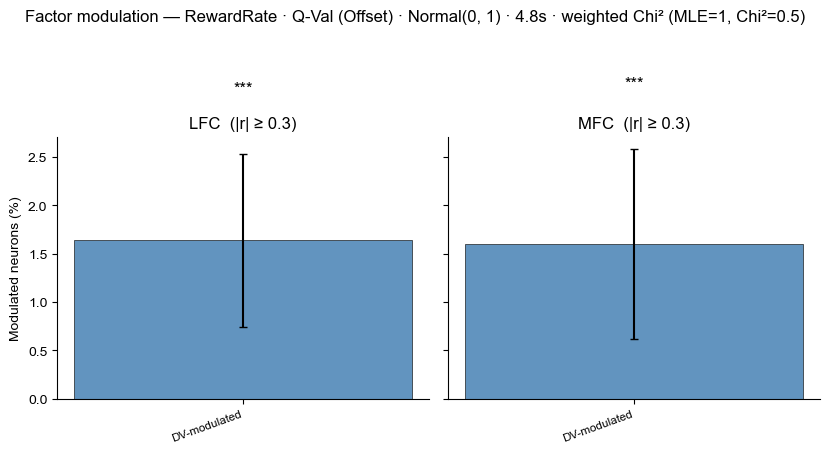

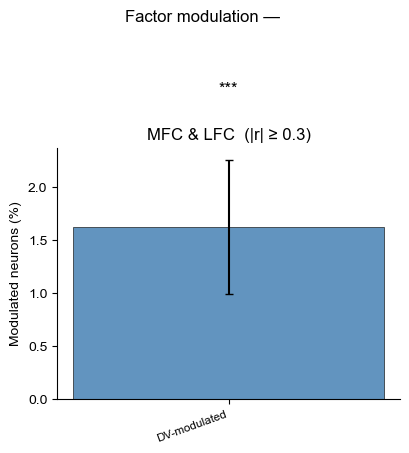

In [13]:
# (1) DV over ALL trials (not split fast/slow): % DV-modulated neurons, per
# region + pooled, vs the neuron-level shuffle chance baseline.
dv_factor = [nc.Factor("DV", ("DV",), "DV-modulated", "steelblue")]
_ = nc.plot_factor_bars(corr_all, table, dv_factor, min_abs_corr=MIN_ABS_CORR,
                        n_shuffles=N_SHUFFLES, by_region=True, run_stats=RUN_STATS,
                        save=SAVE_SUMMARY_FIGS, save_root=BASE_SAVE_PATH,
                        model_name=MODEL_NAME)
_ = nc.plot_factor_bars(corr_all, table, dv_factor, min_abs_corr=MIN_ABS_CORR,
                        n_shuffles=N_SHUFFLES, by_region=False, run_stats=RUN_STATS)

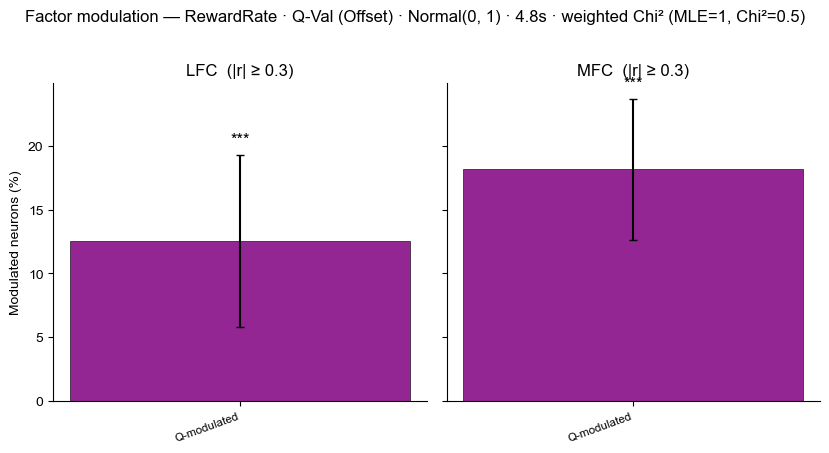

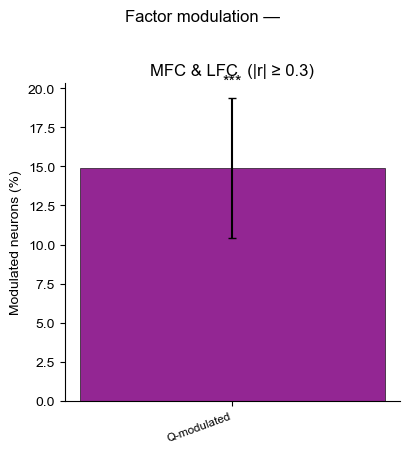

In [14]:
# (2) Q-modulated neurons: Q-left / Q-right / Q-val collapsed into ONE bar. A
# neuron counts if |r| >= MIN_ABS_CORR for any of the three (counted once, since
# corr_all is one row per neuron). Per region + pooled.
q_factor = [nc.Factor("Q", ("Q_L", "Q_R", "Q_val"), "Q-modulated", "purple")]
_ = nc.plot_factor_bars(corr_all, table, q_factor, min_abs_corr=MIN_ABS_CORR,
                        n_shuffles=N_SHUFFLES, by_region=True, run_stats=RUN_STATS,
                        save=SAVE_SUMMARY_FIGS, save_root=BASE_SAVE_PATH,
                        model_name=MODEL_NAME)
_ = nc.plot_factor_bars(corr_all, table, q_factor, min_abs_corr=MIN_ABS_CORR,
                        n_shuffles=N_SHUFFLES, by_region=False, run_stats=RUN_STATS)

c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\rlmodel\model\neural_correlate.py:1580: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.tight_layout()
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\rlmodel\model\neural_correlate.py:1580: UserWarning: Glyph 8851 (\N{SQUARE CAP}) missing from font(s) Arial.
  fig.tight_layout()
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\rlmodel\model\neural_correlate.py:1580: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.tight_layout()
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\rlmodel\model\neural_correlate.py:1580: UserWarning: Glyph 8851 (\N{SQUARE CAP}) missing from font(s) Arial.
  fig.tight_layout()
c:\Users\float\miniconda3\envs\py312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fi

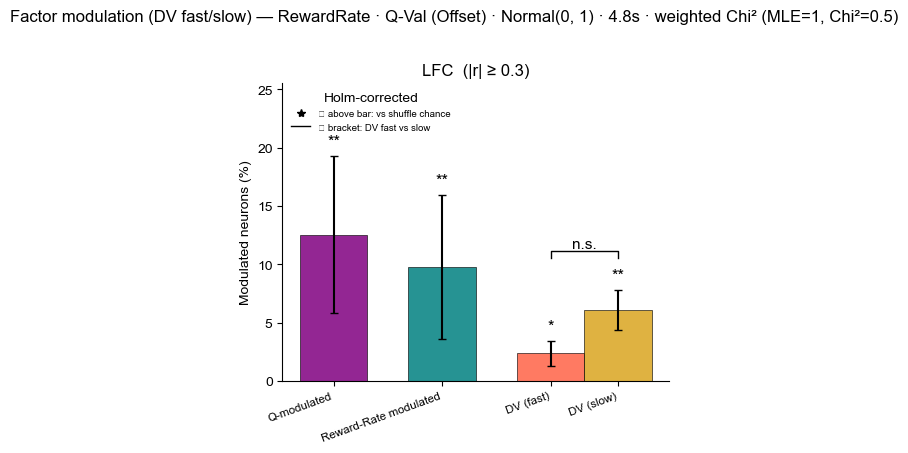

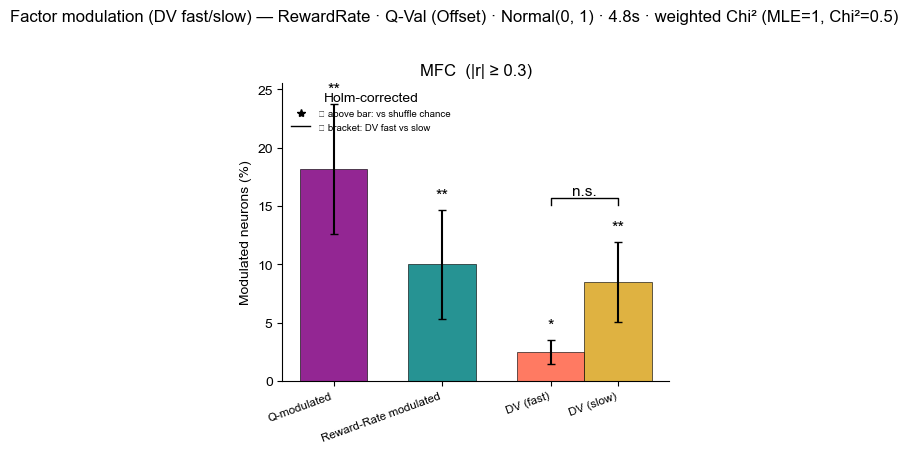

c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\rlmodel\model\neural_correlate.py:1580: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.tight_layout()
c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\rlmodel\model\neural_correlate.py:1580: UserWarning: Glyph 8851 (\N{SQUARE CAP}) missing from font(s) Arial.
  fig.tight_layout()
c:\Users\float\miniconda3\envs\py312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\float\miniconda3\envs\py312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8851 (\N{SQUARE CAP}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


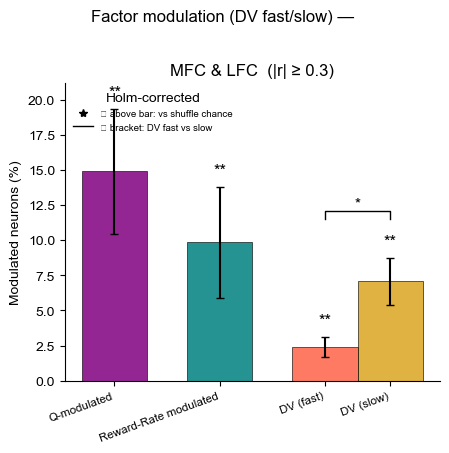

In [20]:
# (3) Compare the main decision drivers side by side: Q-modulated vs
# Reward-Rate-modulated vs DV, with DV split into fast (tomato) | slow
# (goldenrod) TOUCHING sub-bars. DV fast/slow are the % DV-correlated neurons
# WITHIN each RT-tercile subset. With by_region=True each region (MFC, LFC) is
# drawn as its OWN figure on a shared y-range (no cross-region comparison); each
# bar's star tests it vs its per-neuron activity-shuffle chance level (Holm
# across the 4 bars within that region), and the bracket over the DV pair is the
# session-paired DV fast-vs-slow permutation. by_region=False is a single pooled
# figure with the same vs-chance stars.
_ = nc.plot_factor_bars_fastslow_dv(corr_all, table, min_abs_corr=MIN_ABS_CORR,
                        n_shuffles=N_SHUFFLES, n_perm=N_PERM,
                        by_region=True, run_stats=RUN_STATS, save=SAVE_SUMMARY_FIGS,
                        save_root=BASE_SAVE_PATH, model_name=MODEL_NAME)
# ... and pooled across regions:
_ = nc.plot_factor_bars_fastslow_dv(corr_all, table, min_abs_corr=MIN_ABS_CORR,
                        n_shuffles=N_SHUFFLES, n_perm=N_PERM,
                        by_region=False, run_stats=RUN_STATS)

# Fast vs slow: drift-correlated neurons

Same tuned criterion (Pearson r of per-trial max activity vs the drift value,
`|r| >= MIN_ABS_CORR`), but the drift value is the trial's **DV** (signed
evidence) and, separately, **DVabs** (=|DV|). Correlations are computed **within**
the fast (`quantile_idx==1`) and slow (`quantile_idx==3`) trial subsets
separately. The summary bars compare each region — and all regions pooled — fast
vs slow (session mean ± SEM), with permutation / bootstrap significance layered
on (see below).

In [16]:
# Per-neuron DV / DVabs correlations, computed within the fast and slow subsets.
corr_fast, corr_slow = nc.drift_correlations(table)
print("fast neurons:", len(corr_fast), " slow neurons:", len(corr_slow))
corr_fast.head()

fast neurons: 584  slow neurons: 584


,trace_id,long_trace_id,BrainRegion,ShortName,n_trials,DV_r,DV_p,DVabs_r,DVabs_p
0,1,GP4_24_s4_L85_D250_M2_1,MFC,GP4_24_s4_L85_D250_M2,60,-0.342995,0.007300,0.182082,0.163800
1,10,GP4_24_s4_L85_D250_M2_10,MFC,GP4_24_s4_L85_D250_M2,60,-0.046757,0.722773,0.224234,0.085000
2,114,GP4_24_s4_L85_D250_M2_114,MFC,GP4_24_s4_L85_D250_M2,60,0.063333,0.630702,-0.073248,0.578081
3,12,GP4_24_s4_L85_D250_M2_12,MFC,GP4_24_s4_L85_D250_M2,60,0.103604,0.430840,-0.196349,0.132684
4,13,GP4_24_s4_L85_D250_M2_13,MFC,GP4_24_s4_L85_D250_M2,60,-0.082708,0.529836,0.169391,0.195711


## Fast-vs-slow summary bars

Per-session % drift-correlated neurons, fast (tomato) vs slow (goldenrod), for
DV and DVabs. `by_region=True` → one fast/slow pair per MFC/LFC (4 bars);
`by_region=False` → all regions pooled (2 bars). Bars are session mean ± SEM.

Three significance layers (all Holm-corrected within their family, gated by
`RUN_STATS`): a **vs-chance** star above each bar (per-neuron activity shuffle —
needs `table`); a session-**paired fast-vs-slow** permutation bracket per region;
and, in the by-region view, **MFC-vs-LFC** hierarchical-bootstrap brackets within
each speed.

	LFC: fast 2.36±1.08% (7 sess) | slow 6.07±1.74% (7 sess)
	MFC: fast 2.49±1.01% (5 sess) | slow 8.46±3.44% (5 sess)


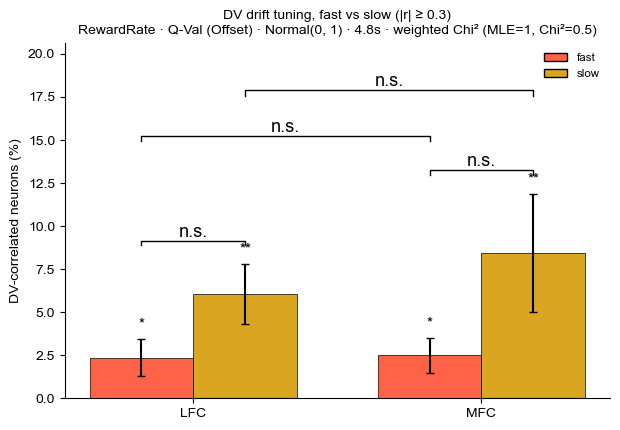

	MFC & LFC: fast 2.41±0.73% (12 sess) | slow 7.06±1.70% (12 sess)


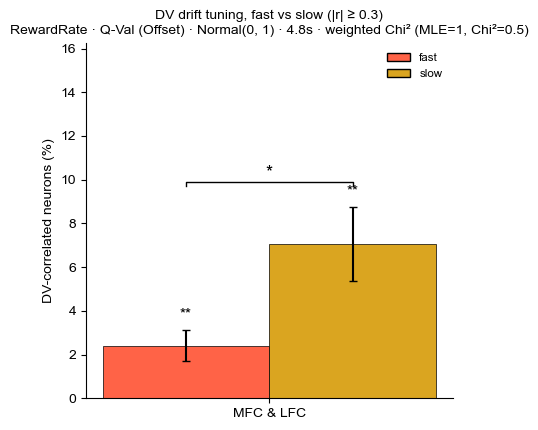

	LFC: fast 1.26±1.01% (7 sess) | slow 2.42±1.41% (7 sess)
	MFC: fast 0.00±0.00% (5 sess) | slow 4.54±2.47% (5 sess)


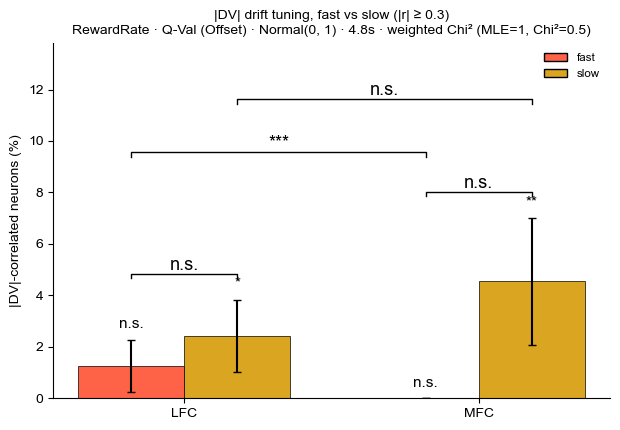

	MFC & LFC: fast 0.73±0.60% (12 sess) | slow 3.31±1.29% (12 sess)


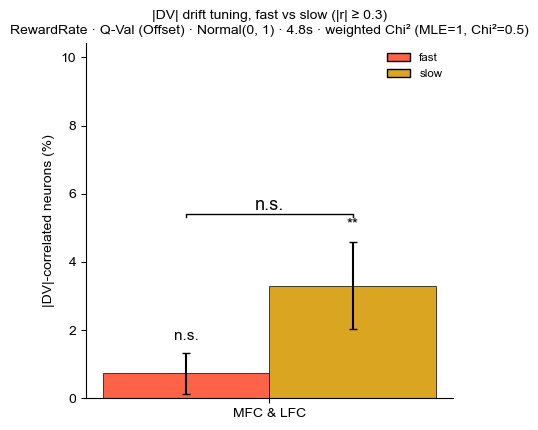

In [17]:
# Fast-vs-slow summary bars: per region (4 bars) and all-regions pooled (2 bars),
# for DV and for DVabs. Passing `table` enables the per-bar vs-chance shuffle
# test; each bar also carries a session-paired fast-vs-slow permutation, and the
# by-region view adds MFC-vs-LFC hierarchical-bootstrap brackets within each
# speed. Set RUN_STATS=False in Config for a fast plot-only pass.
for drift in ("DV", "DVabs"):
    nc.plot_fast_slow_bars(corr_fast, corr_slow, drift, table=table,
                           min_abs_corr=MIN_ABS_CORR, n_perm=N_PERM, n_boot=N_BOOT,
                           by_region=True, run_stats=RUN_STATS,
                           save=SAVE_SUMMARY_FIGS,
                           save_root=BASE_SAVE_PATH, model_name=MODEL_NAME)
    nc.plot_fast_slow_bars(corr_fast, corr_slow, drift, table=table,
                           min_abs_corr=MIN_ABS_CORR, n_perm=N_PERM, n_boot=N_BOOT,
                           by_region=False, run_stats=RUN_STATS,
                           save=SAVE_SUMMARY_FIGS,
                           save_root=BASE_SAVE_PATH, model_name=MODEL_NAME)

## Per-neuron fast/slow scatters

Fast (tomato) and slow (goldenrod) trials overlaid on one axes, each with its
own fit line + r/p. Neurons ranked by `max(|r_fast|, |r_slow|)`; display shows
the top-`TOP_X`, save writes the drift-correlated subset under
`{model}/drift_scatter/{drift}/`.

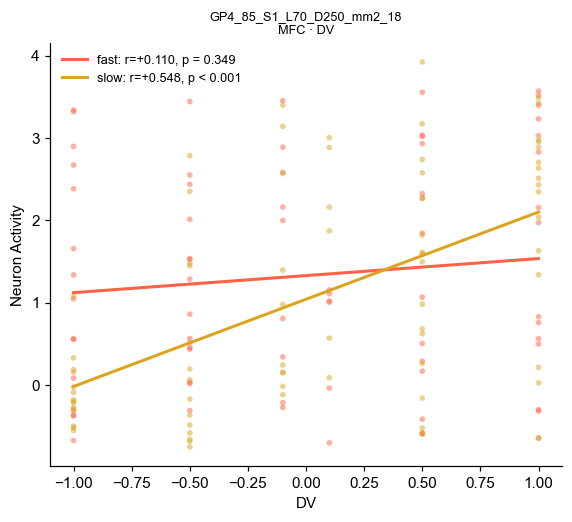

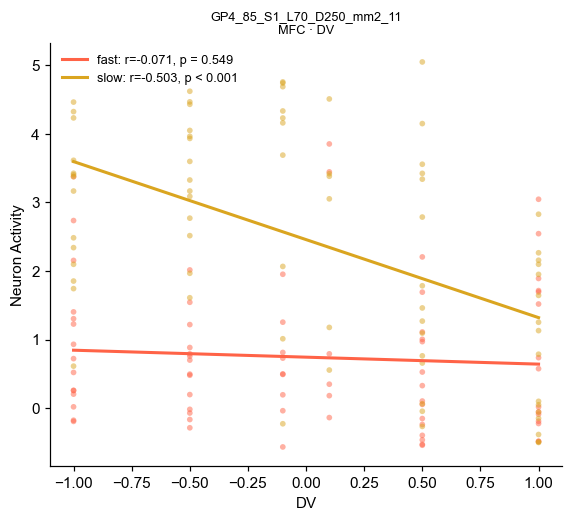

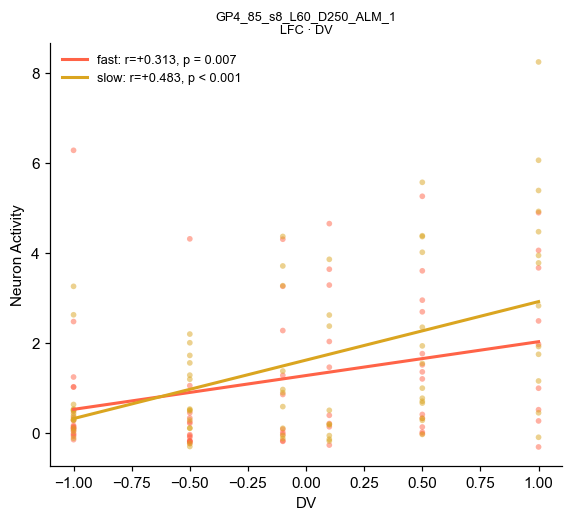

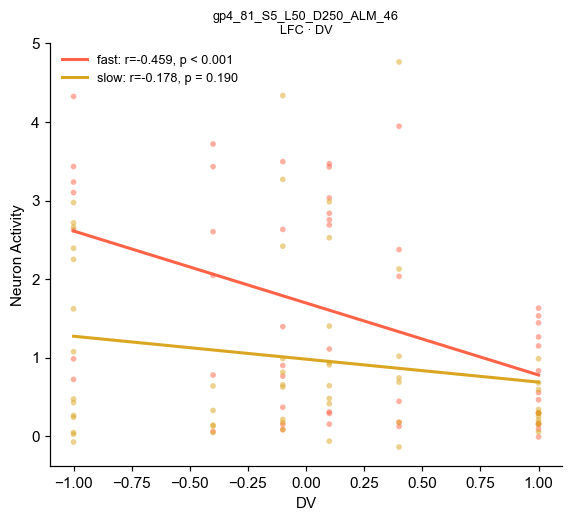

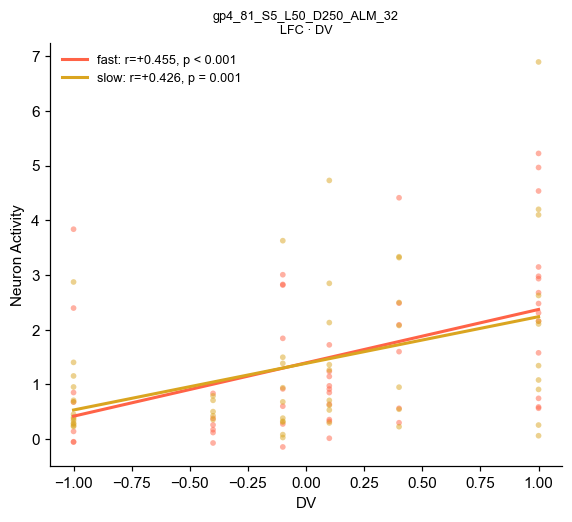

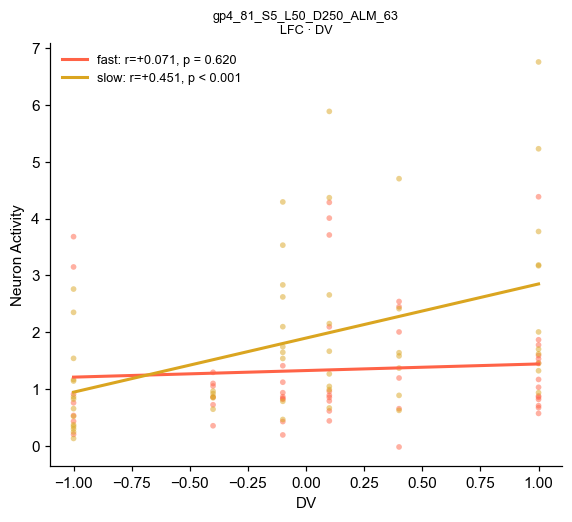

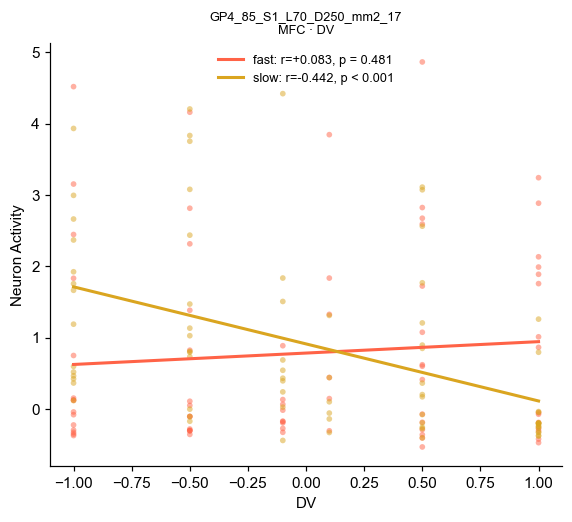

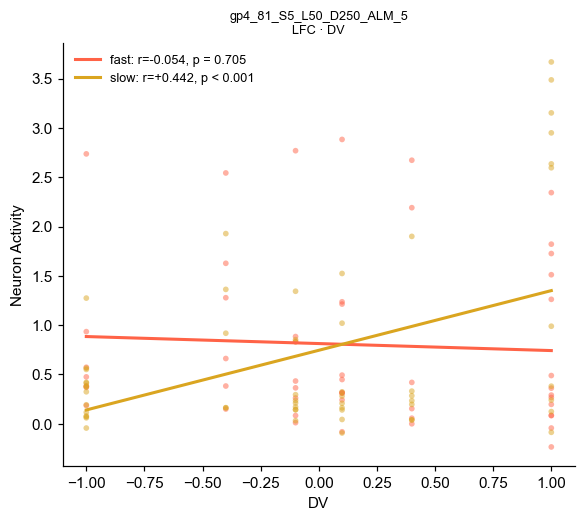

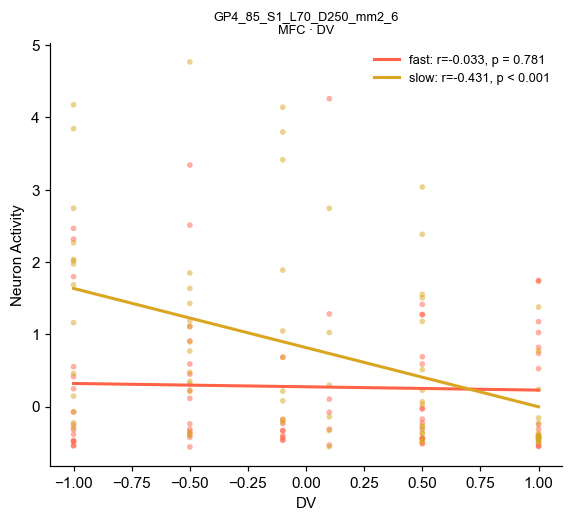

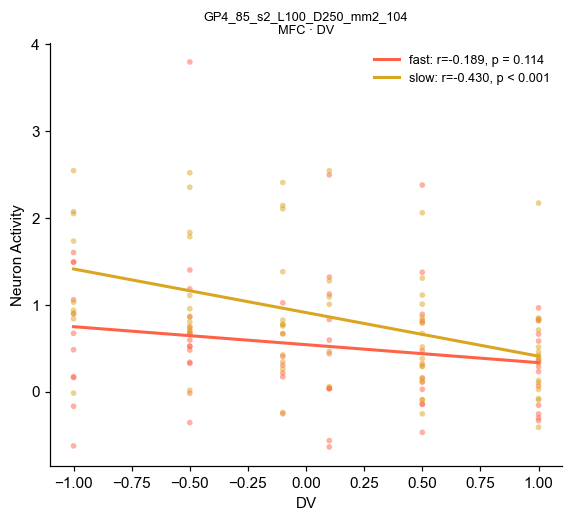

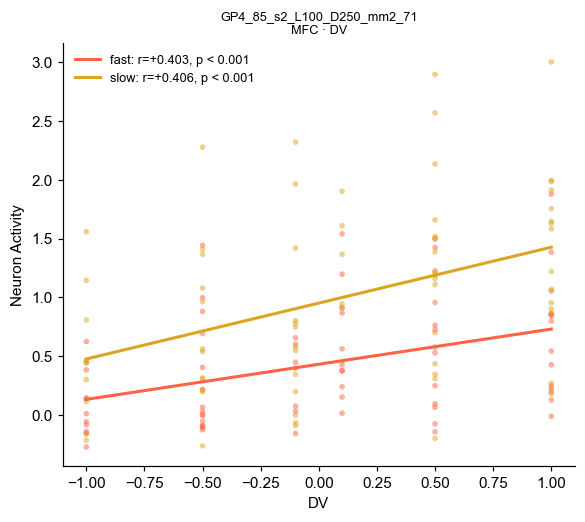

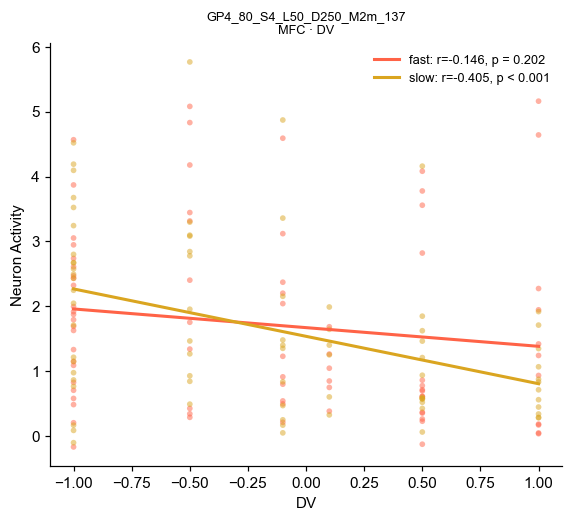

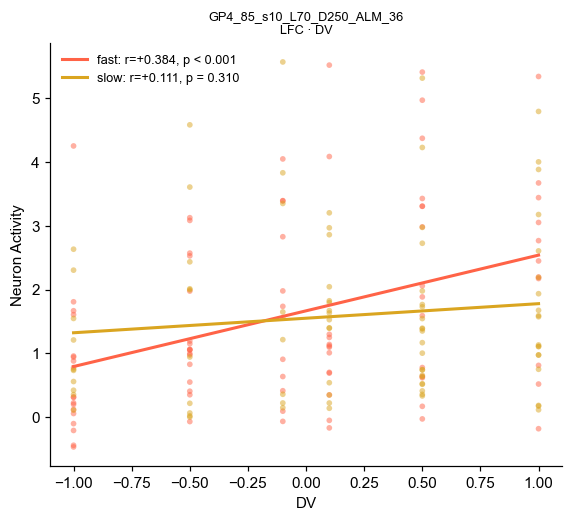

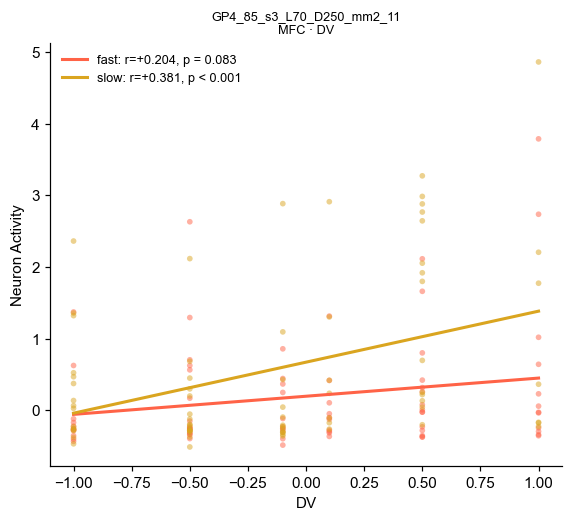

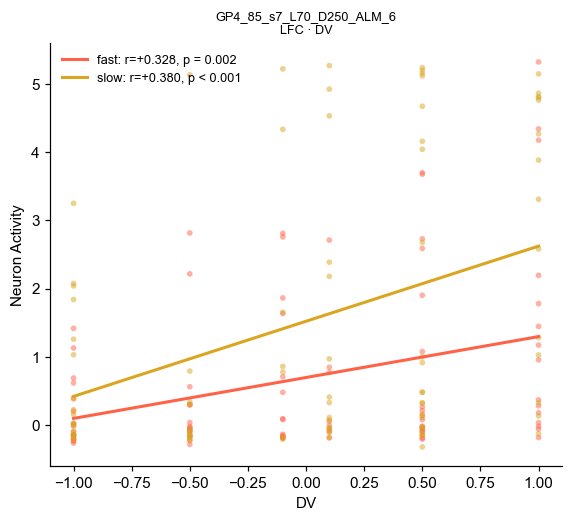

In [18]:
# Per-neuron scatters, fast (tomato) & slow (goldenrod) overlaid, top-TOP_X by
# max(|r_fast|, |r_slow|). Each speed gets its own fit line + r/p in the legend.
_DRIFT = "DV"   # or "DVabs"
_ = nc.plot_neuron_fastslow_scatter(table, corr_fast, corr_slow, _DRIFT,
                                    mode="display", top_x=TOP_X)

# Save the drift-correlated subset (max(|r_fast|,|r_slow|) >= MIN_ABS_CORR):
#   {BASE_SAVE_PATH}/{model}/drift_scatter/{drift}/f{rf}_s{rs}_{long_name}[_region].svg
# Gated by SAVE_NEURON_FIGS (Config) — one file per drift-correlated neuron.
if SAVE_NEURON_FIGS:
    for drift in ("DV", "DVabs"):
        nc.plot_neuron_fastslow_scatter(table, corr_fast, corr_slow, drift,
                                        mode="save", min_abs_corr=MIN_ABS_CORR,
                                        save_root=BASE_SAVE_PATH, model_name=MODEL_NAME)

## Per-neuron fast/slow traces

Two-panel (Fast | Slow) time-normalized traces, averaged within each
`DRIFT_VALUE_RANGES` bin and gradient-coloured. For the signed **DV**, the
gradient encodes only the range's magnitude (so ±1 share a shade) and the
negative-DV ranges are drawn dashed; **DVabs** is a plain light→dark gradient.

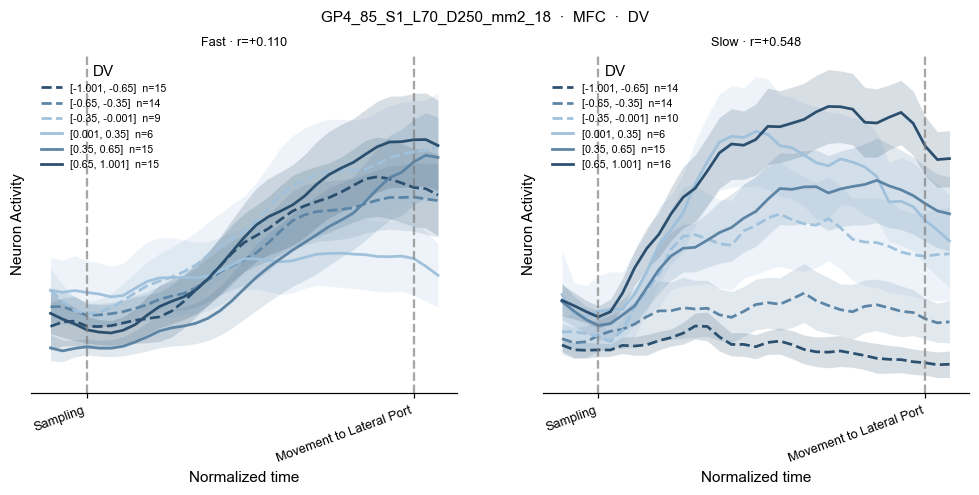

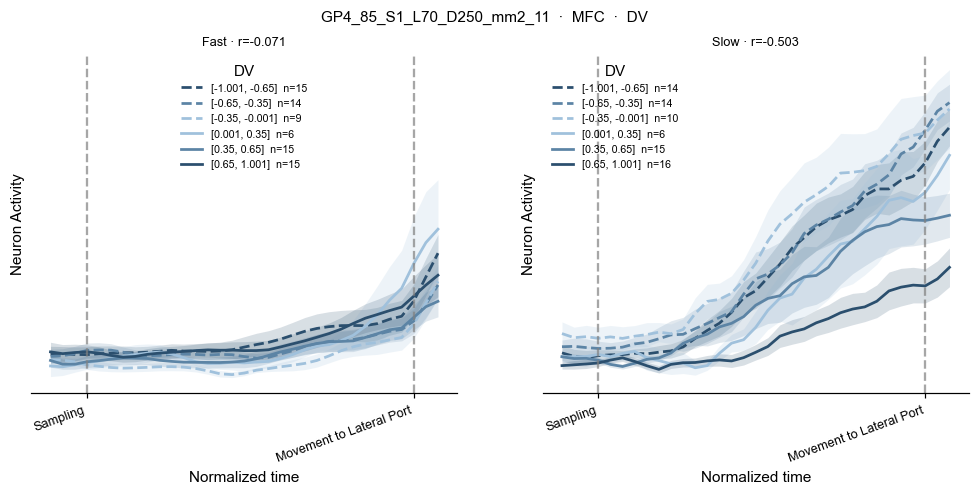

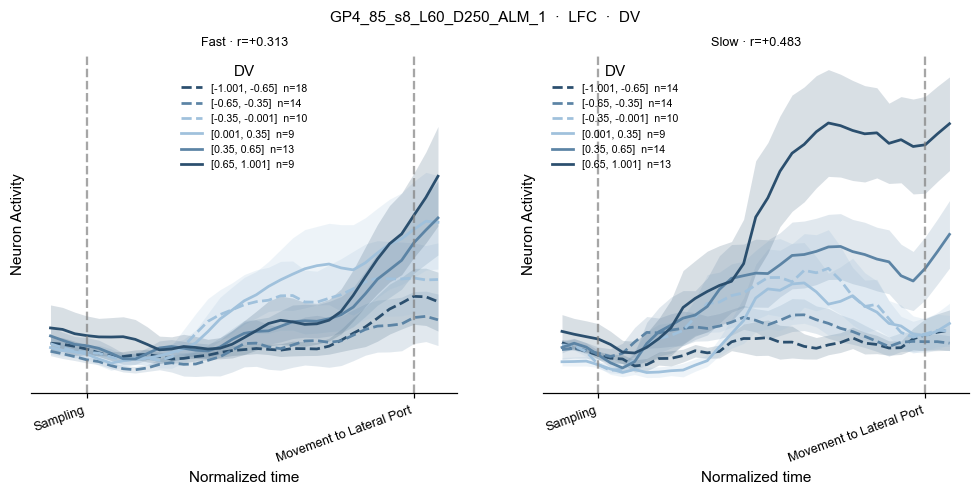

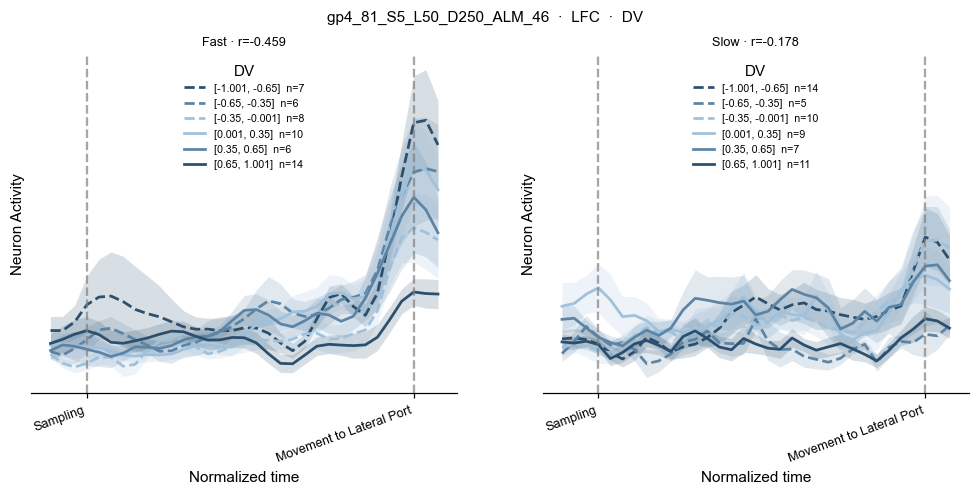

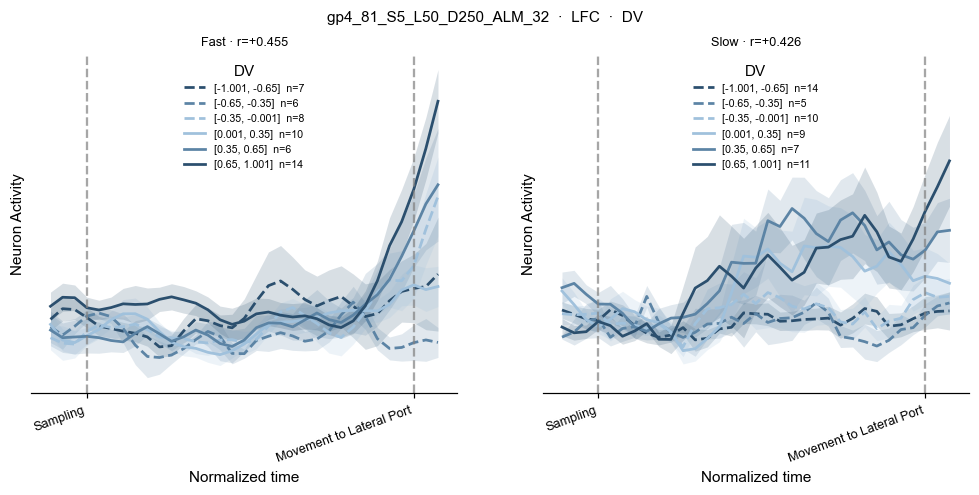

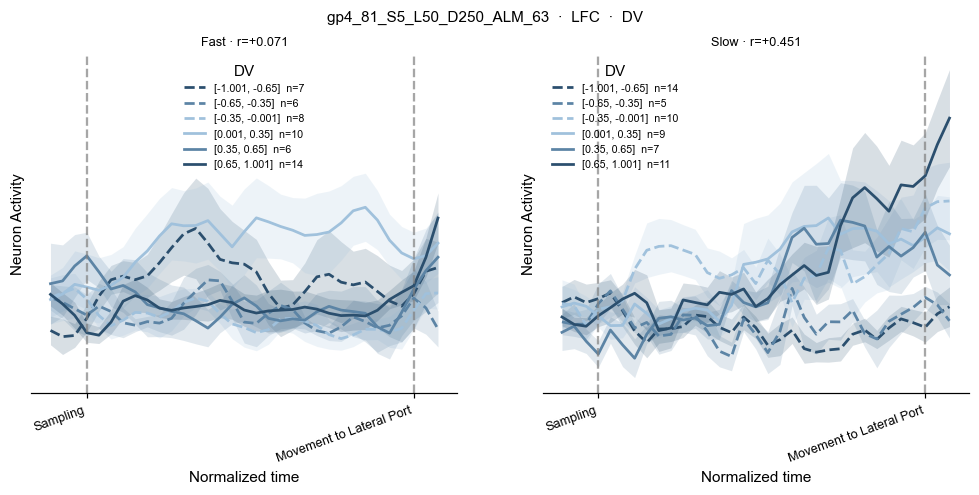

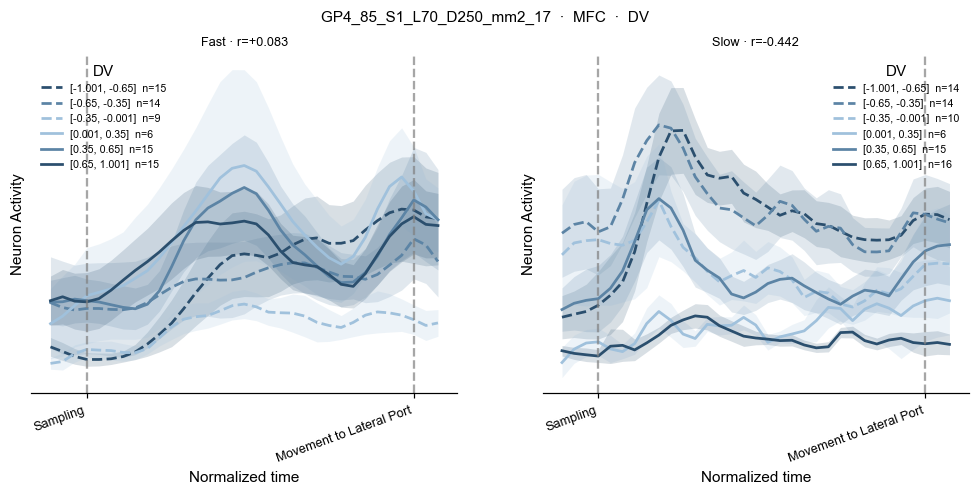

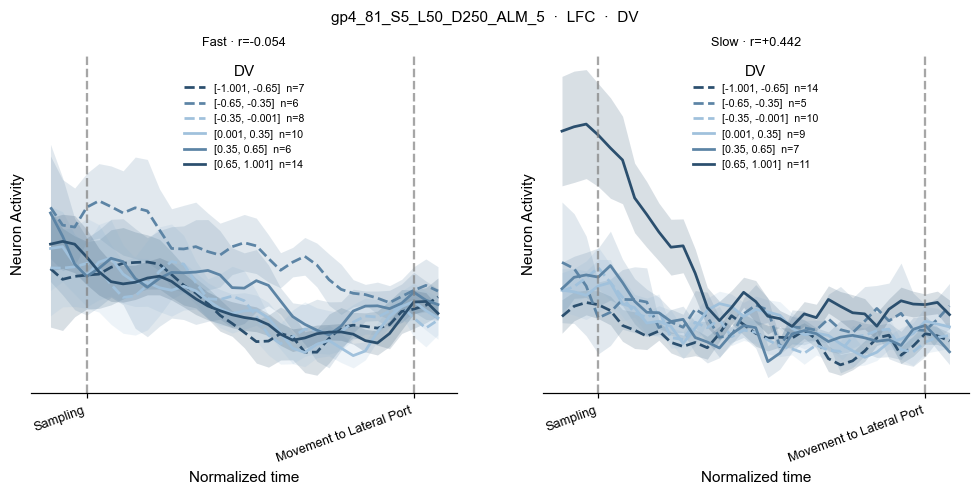

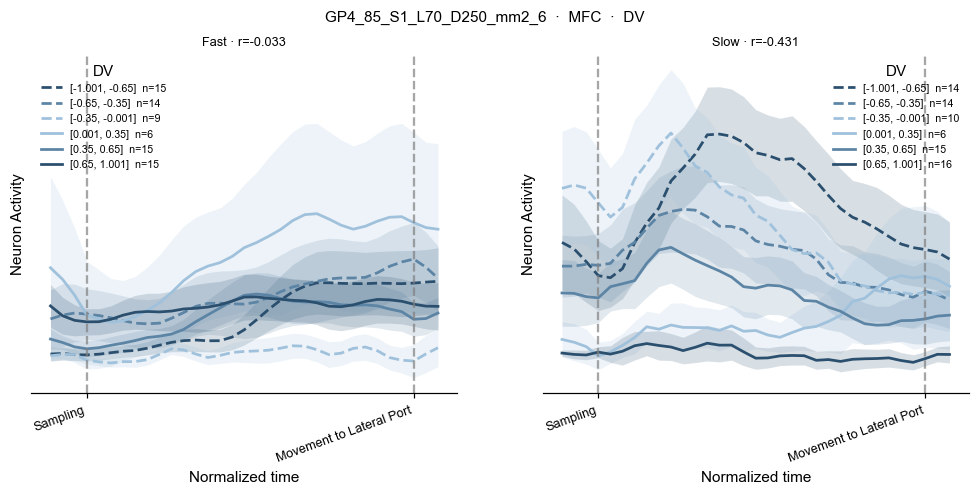

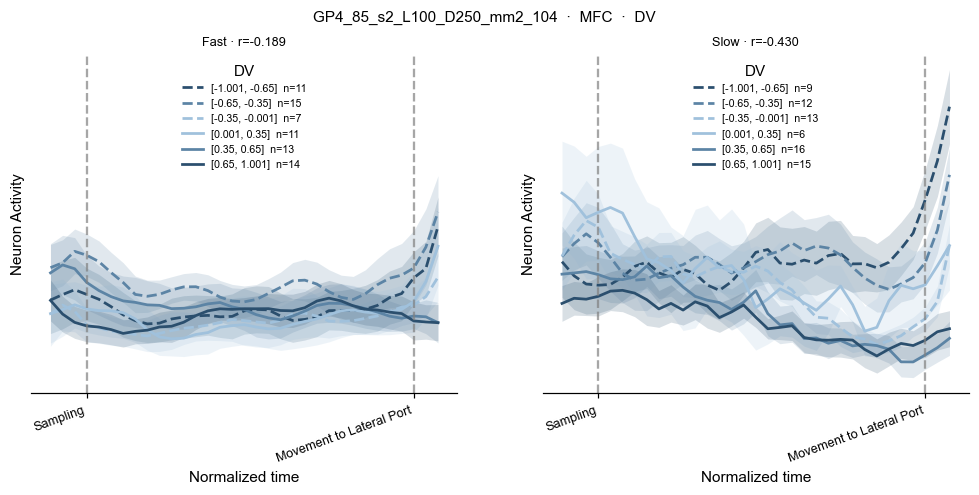

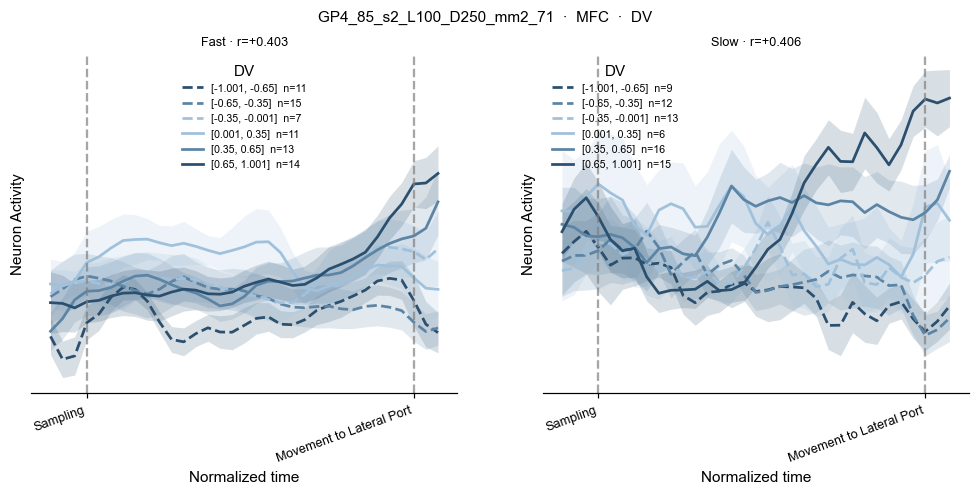

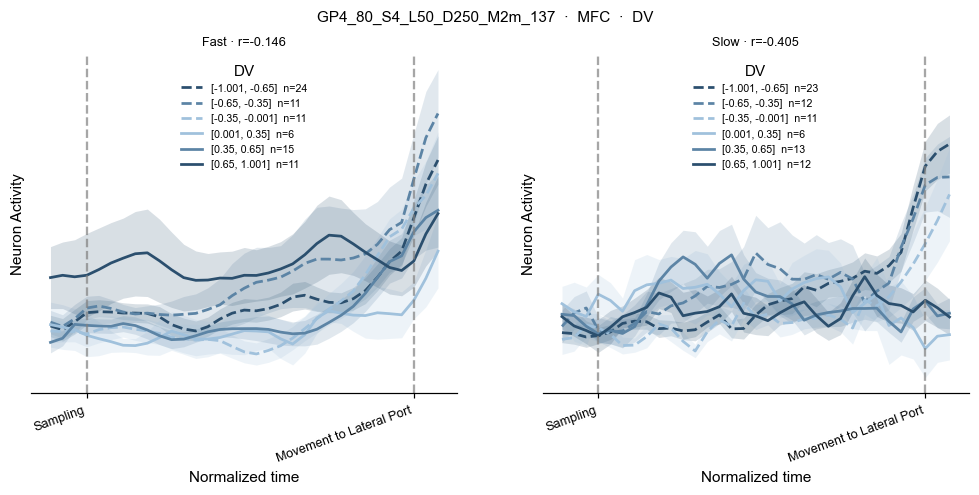

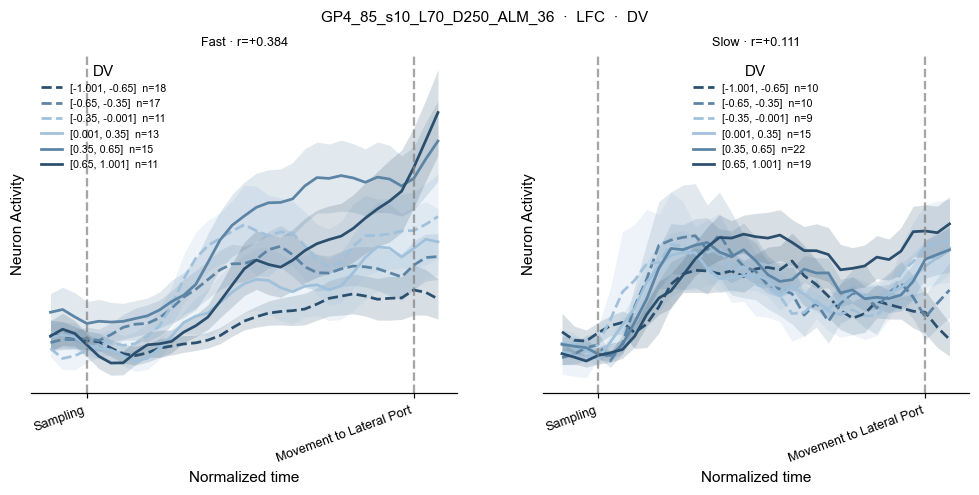

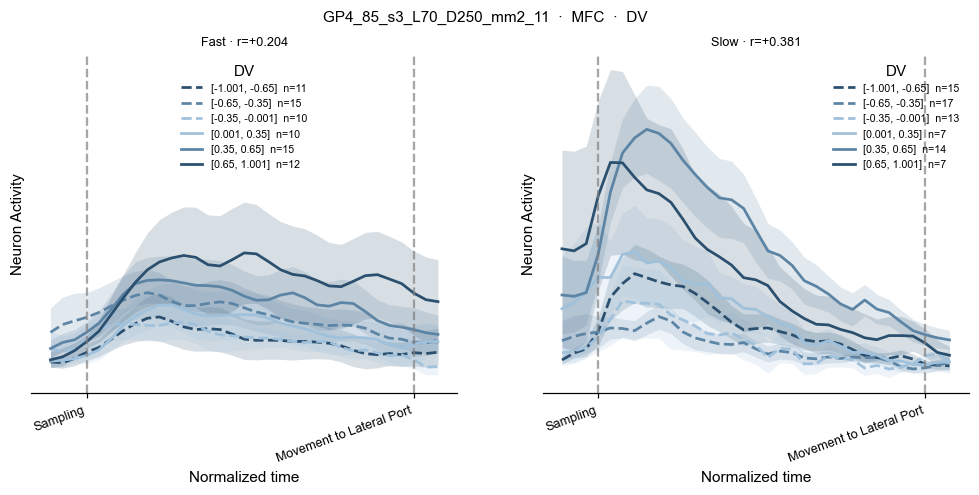

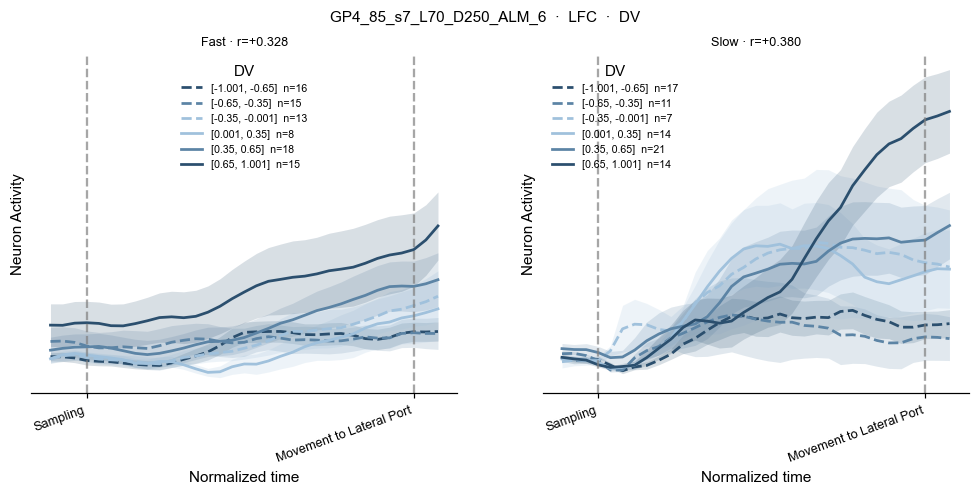

NameError: name 'SAVE_NETrueURON_FIGS' is not defined

In [19]:
# Per-neuron normalized traces, Fast | Slow two-panel, gradient by DRIFT range.
_DRIFT = "DV"   # or "DVabs"
_ = nc.plot_neuron_fastslow_traces(table, corr_fast, corr_slow, _DRIFT,
                                   DRIFT_VALUE_RANGES[_DRIFT],
                                   mode="display", top_x=TOP_X)

# Save the drift-correlated subset under {model}/drift_traces/{drift}/:
# Gated by SAVE_NEURON_FIGS (Config) — one file per drift-correlated neuron.
if SAVE_NETrueURON_FIGS:
    for drift in ("DV", "DVabs"):
        nc.plot_neuron_fastslow_traces(table, corr_fast, corr_slow, drift,
                                       DRIFT_VALUE_RANGES[drift], mode="save",
                                       min_abs_corr=MIN_ABS_CORR,
                                       save_root=BASE_SAVE_PATH, model_name=MODEL_NAME)